# Notebook 4: Non-IB Customer — Cluster Profiling & Business Insights

**G'CONTEST 2026 — Chân dung & Chiến lược cho khách hàng Non-IB**

Mục tiêu:
1. Phân tích đặc trưng từng cụm (Persona)
2. Đặt tên Persona bằng ngôn ngữ kinh doanh
3. Kiểm định thống kê sự khác biệt giữa các cụm
4. Visualization suite (Radar, Parallel Coordinates, Box Plots)
5. Đề xuất chiến lược Cross-selling & O2O cho mỗi Persona

**Input:** `output/nonib_clustered.parquet`

In [1]:
# ============================================================
# IMPORTS
# ============================================================
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'Cluster_nonIB':
    PROJECT_DIR = PROJECT_DIR.parent

CLUSTER_DIR = PROJECT_DIR / 'Cluster_nonIB'
OUTPUT_DIR = CLUSTER_DIR / 'output'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Ready.')

Ready.


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_parquet(OUTPUT_DIR / 'nonib_clustered.parquet')

# Load clustering metadata
with open(OUTPUT_DIR / 'clustering_metadata.json', 'r') as f:
    meta = json.load(f)

CHOSEN_K = meta['chosen_k']

print(f'Dataset: {df.shape}')
print(f'Chosen K: {CHOSEN_K}')
print(f'Silhouette Score: {meta["silhouette_score"]:.4f}')
print(f'\nCluster distribution:')
print(df['CLUSTER'].value_counts().sort_index())

Dataset: (127000, 54)
Chosen K: 8
Silhouette Score: 0.6821

Cluster distribution:
CLUSTER
-1    24570
 0    80038
 1      493
 2      562
 3      912
 4      800
 5    13178
 6     5794
 7      653
Name: count, dtype: int64


---
## 1. Cluster Summary Table

In [3]:
# ----------------------------------------------------------
# Core profiling features
# ----------------------------------------------------------
PROFILE_FEATURES = [
    'AGE', 'TENURE_DAYS',
    'CA_BALANCE_MEAN', 'TD_BALANCE_MEAN',
    'CA_BALANCE_TREND', 'TD_BALANCE_TREND',
    'CA_BALANCE_STD', 'TD_TO_TOTAL_RATIO',
    'LOAN_AMOUNT_MEAN', 'LOAN_TREND', 'LOAN_COUNT_MAX',
    'CREDITCARD_MAX', 'DEBITCARD_MAX',
    'PRODUCT_COUNT', 'NET_WORTH_PROXY', 'SAVINGS_RATE',
    'MONTHS_WITH_DEPOSIT',
]

# Active clusters only (excluding dormant = -1)
df_active = df[df['CLUSTER'] >= 0].copy()

# Cluster summary: mean of each feature
cluster_summary = df_active.groupby('CLUSTER')[PROFILE_FEATURES].mean()
cluster_summary['COUNT'] = df_active.groupby('CLUSTER').size()
cluster_summary['PCT'] = (cluster_summary['COUNT'] / len(df) * 100).round(1)

print('Cluster Summary (Mean Values):')
display(cluster_summary.round(2))

Cluster Summary (Mean Values):


,AGE,TENURE_DAYS,CA_BALANCE_MEAN,TD_BALANCE_MEAN,CA_BALANCE_TREND,TD_BALANCE_TREND,CA_BALANCE_STD,TD_TO_TOTAL_RATIO,LOAN_AMOUNT_MEAN,LOAN_TREND,LOAN_COUNT_MAX,CREDITCARD_MAX,DEBITCARD_MAX,PRODUCT_COUNT,NET_WORTH_PROXY,SAVINGS_RATE,MONTHS_WITH_DEPOSIT,COUNT,PCT
CLUSTER,,,,,,,,,,,,,,,,,,,
0,36.84,183.51,1310268.54,1.394924e+07,37782.74,0.000000e+00,979238.77,0.05,1.908733e+08,-977862.22,0.48,0.05,0.43,1.77,-1.756138e+08,0.05,4.85,80038,63.0
1,38.90,267.35,1419530.27,1.015421e+08,-247383.97,7.701079e+06,1932752.43,0.49,2.295790e+08,-274652.84,1.24,1.36,0.00,2.59,-1.266173e+08,0.32,3.96,493,0.4
2,45.89,234.63,896227.54,2.468124e+08,29321.52,1.910522e+07,349217.70,0.99,3.039079e+08,0.00,1.03,0.00,0.00,2.77,-5.619932e+07,0.48,6.95,562,0.4
3,47.85,128.72,146292.76,5.014105e+08,47478.38,3.863430e+08,94388.47,1.00,0.000000e+00,0.00,0.00,0.00,0.00,1.31,5.015568e+08,1.00,2.61,912,0.7
4,46.38,171.76,1699957.39,2.686769e+08,163837.19,-1.676131e+08,2461743.39,0.99,9.952049e+07,0.00,0.10,0.00,0.00,2.08,1.708563e+08,0.93,5.52,800,0.6
5,43.84,187.09,13036.98,1.174149e+08,1561.08,1.197285e+07,4394.44,1.00,0.000000e+00,0.00,0.00,0.00,0.00,1.46,1.174280e+08,1.00,5.75,13178,10.4
6,47.82,188.21,1197314.49,2.157829e+08,-57894.53,3.433643e+07,1441296.89,0.98,0.000000e+00,0.00,0.00,0.00,0.07,2.07,2.169803e+08,0.98,5.80,5794,4.6
7,43.09,223.35,4670731.21,1.042318e+08,-166787.14,-2.375661e+06,5613689.81,0.88,7.450047e+08,-2690980.97,1.25,0.01,0.21,3.08,-6.361022e+08,0.17,7.53,653,0.5


In [4]:
# Product penetration per cluster
product_flags = ['HAS_CA', 'HAS_TD', 'HAS_CREDIT_CARD', 'HAS_DEBIT_CARD', 'HAS_LOAN']

product_penetration = df_active.groupby('CLUSTER')[product_flags].mean() * 100
product_penetration['PRODUCT_COUNT_MEAN'] = df_active.groupby('CLUSTER')['PRODUCT_COUNT'].mean()

print('Product Penetration per Cluster (%):')
display(product_penetration.round(1))

Product Penetration per Cluster (%):


,HAS_CA,HAS_TD,HAS_CREDIT_CARD,HAS_DEBIT_CARD,HAS_LOAN,PRODUCT_COUNT_MEAN
CLUSTER,,,,,,
0,81.5,5.4,5.5,41.3,43.2,1.8
1,44.2,50.7,76.3,0.0,87.6,2.6
2,79.2,100.0,0.0,0.0,98.2,2.8
3,30.9,100.0,0.0,0.0,0.0,1.3
4,100.0,100.0,0.0,0.0,8.5,2.1
5,45.8,100.0,0.0,0.0,0.0,1.5
6,100.0,100.0,0.0,7.3,0.0,2.1
7,96.3,100.0,0.8,17.5,93.7,3.1


In [5]:
# Gender and Age Group distribution per cluster
gender_dist = pd.crosstab(df_active['CLUSTER'], df_active['CLIENT_SEX'], normalize='index') * 100
print('Gender Distribution per Cluster (%):')
display(gender_dist.round(1))

age_dist = pd.crosstab(df_active['CLUSTER'], df_active['AGE_GROUP'], normalize='index') * 100
print('\nAge Group Distribution per Cluster (%):')
display(age_dist.round(1))

Gender Distribution per Cluster (%):


CLIENT_SEX,F,M
CLUSTER,,
0,46.2,53.8
1,53.1,46.9
2,65.8,34.2
3,57.8,42.2
4,56.2,43.8
5,65.8,34.2
6,64.9,35.1
7,51.3,48.7



Age Group Distribution per Cluster (%):


AGE_GROUP,<25,25-35,35-45,45-55,55+
CLUSTER,,,,,
0,18.0,31.9,25.9,14.9,9.4
1,4.7,38.7,31.6,14.6,10.3
2,2.8,22.2,27.2,20.6,27.0
3,2.7,14.5,26.1,25.3,31.4
4,1.8,18.6,28.5,24.8,26.4
5,5.6,28.4,23.3,16.8,26.0
6,2.6,19.7,21.7,21.4,34.6
7,2.8,22.7,33.7,25.6,15.3


---
## 2. Radar Chart — Cluster Comparison

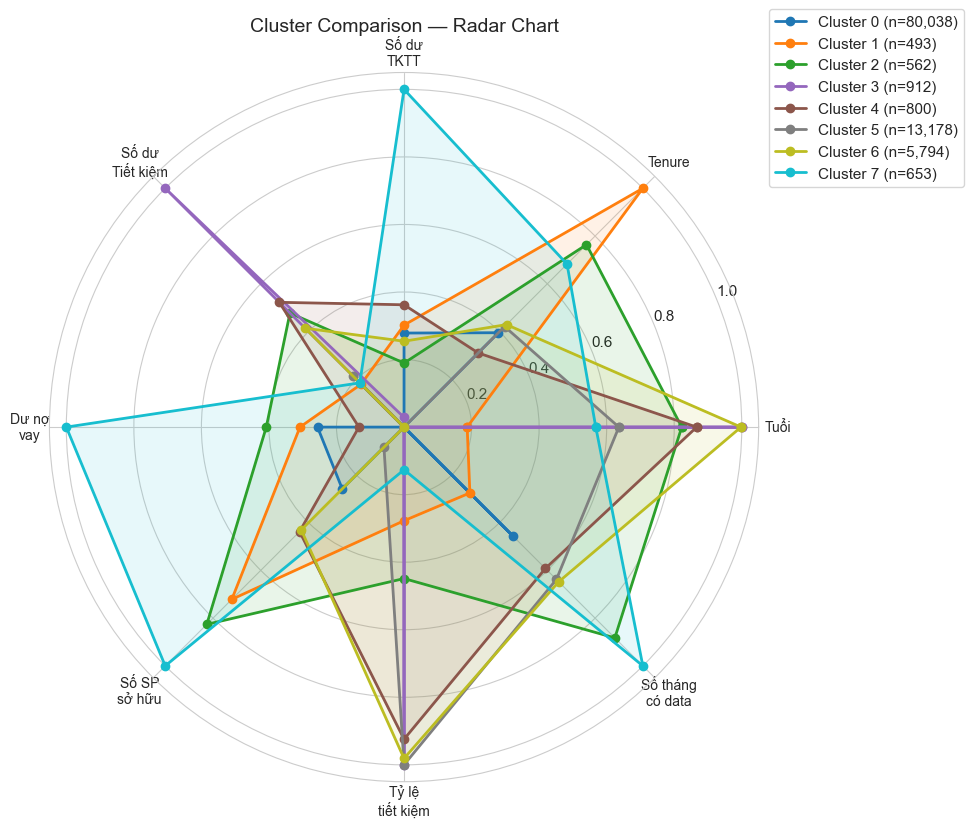

In [6]:
# Radar chart features — normalized to [0, 1] for comparison
radar_features = [
    'AGE', 'TENURE_DAYS', 'CA_BALANCE_MEAN', 'TD_BALANCE_MEAN',
    'LOAN_AMOUNT_MEAN', 'PRODUCT_COUNT', 'SAVINGS_RATE', 'MONTHS_WITH_DEPOSIT'
]
radar_labels = [
    'Tuổi', 'Tenure', 'Số dư\nTKTT', 'Số dư\nTiết kiệm',
    'Dư nợ\nvay', 'Số SP\nsở hữu', 'Tỷ lệ\ntiết kiệm', 'Số tháng\ncó data'
]

# Normalize each feature to [0, 1] across clusters
radar_data = cluster_summary[radar_features].copy()
for col in radar_features:
    col_min = radar_data[col].min()
    col_max = radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)
    else:
        radar_data[col] = 0.5

# Plot
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
cmap = plt.cm.get_cmap('tab10', CHOSEN_K)

for cluster_id in range(CHOSEN_K):
    values = radar_data.loc[cluster_id].values.tolist()
    values += values[:1]  # close
    count = int(cluster_summary.loc[cluster_id, 'COUNT'])
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id} (n={count:,})', color=cmap(cluster_id))
    ax.fill(angles, values, alpha=0.1, color=cmap(cluster_id))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_title('Cluster Comparison — Radar Chart', fontsize=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(FIG_DIR / 'radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Box Plots — Feature Distribution per Cluster

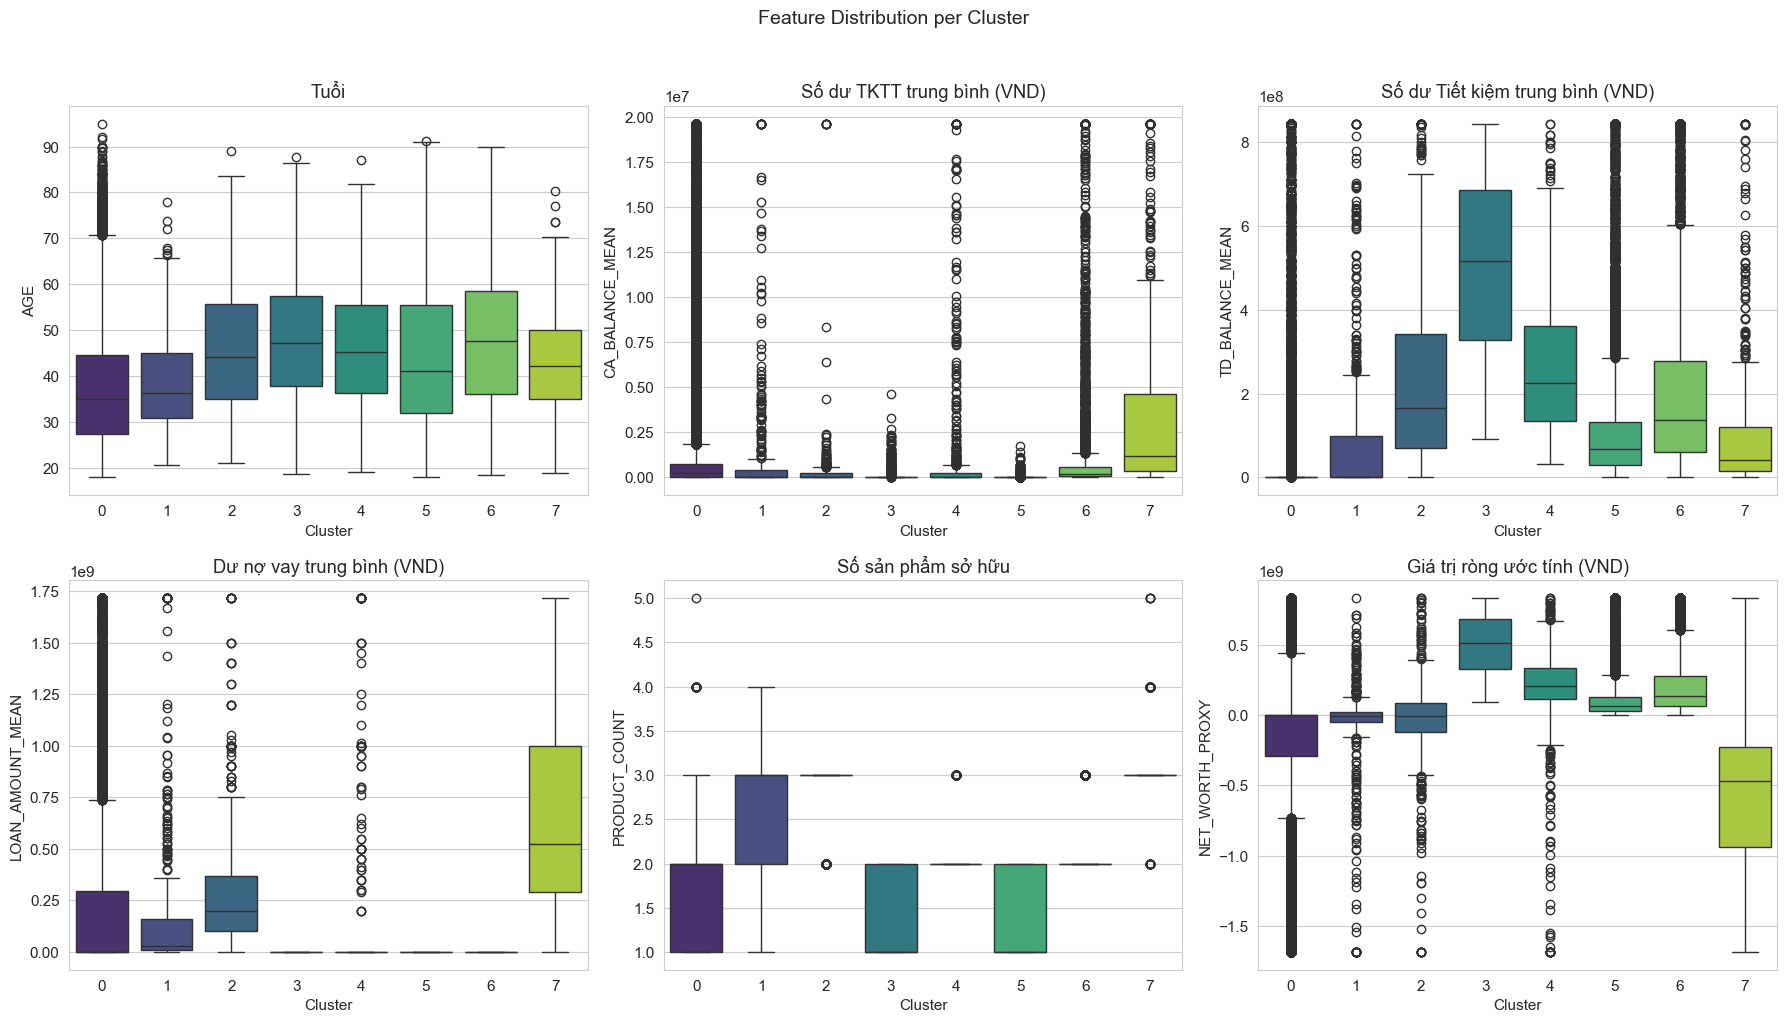

In [7]:
# Key features to compare across clusters
box_features = [
    ('AGE', 'Tuổi'),
    ('CA_BALANCE_MEAN', 'Số dư TKTT trung bình (VND)'),
    ('TD_BALANCE_MEAN', 'Số dư Tiết kiệm trung bình (VND)'),
    ('LOAN_AMOUNT_MEAN', 'Dư nợ vay trung bình (VND)'),
    ('PRODUCT_COUNT', 'Số sản phẩm sở hữu'),
    ('NET_WORTH_PROXY', 'Giá trị ròng ước tính (VND)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, title) in enumerate(box_features):
    data = df_active[[col, 'CLUSTER']].copy()
    # Clip for readability
    if col in ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'LOAN_AMOUNT_MEAN', 'NET_WORTH_PROXY']:
        p99 = data[col].quantile(0.99)
        p1 = data[col].quantile(0.01)
        data[col] = data[col].clip(lower=p1, upper=p99)
    sns.boxplot(data=data, x='CLUSTER', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(title)
    axes[i].set_xlabel('Cluster')

plt.suptitle('Feature Distribution per Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Product Ownership Stacked Bar Chart

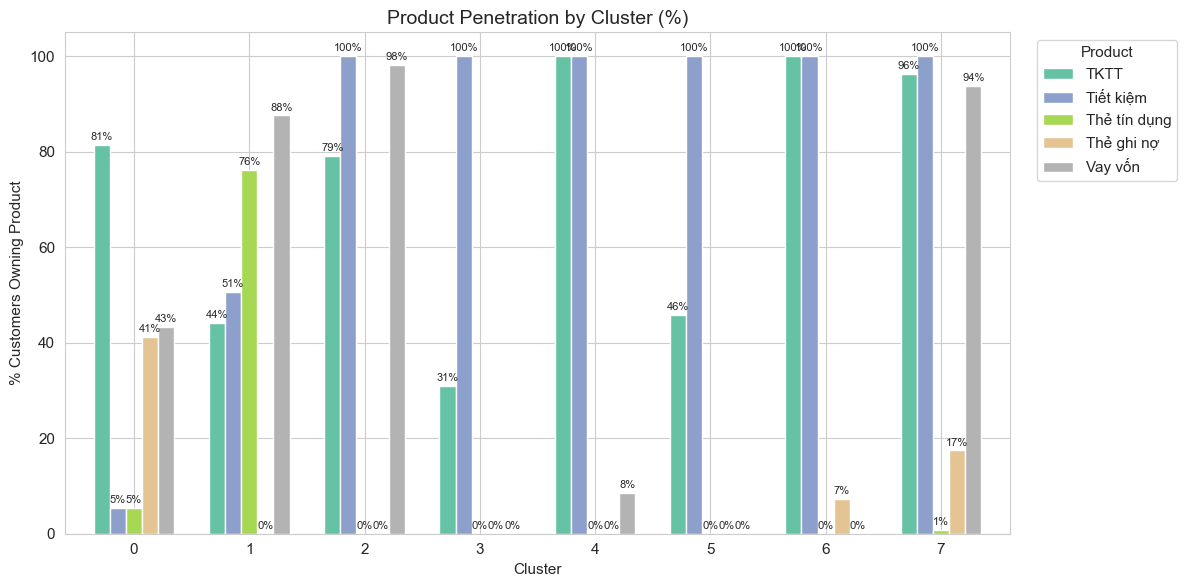

In [8]:
# Stacked bar chart of product ownership per cluster
product_data = product_penetration[product_flags].copy()
product_data.columns = ['TKTT', 'Tiết kiệm', 'Thẻ tín dụng', 'Thẻ ghi nợ', 'Vay vốn']

fig, ax = plt.subplots(figsize=(12, 6))
product_data.plot(kind='bar', ax=ax, width=0.7, colormap='Set2')
ax.set_title('Product Penetration by Cluster (%)', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('% Customers Owning Product')
ax.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'product_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Statistical Validation (Kruskal-Wallis Test)

Kiểm định xem các cụm có thực sự khác nhau có ý nghĩa thống kê không.

In [9]:
# Kruskal-Wallis test (non-parametric ANOVA)
# H0: All clusters have the same distribution for feature X
# Reject H0 if p < 0.05

stat_results = []

for feature in PROFILE_FEATURES:
    groups = [df_active.loc[df_active['CLUSTER'] == c, feature].dropna().values
              for c in range(CHOSEN_K)]
    # Filter out empty groups
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        try:
            stat, pval = stats.kruskal(*groups)
        except ValueError:
            stat = 0.0
            pval = 1.0
            
        stat_results.append({
            'Feature': feature,
            'H-statistic': stat,
            'p-value': pval,
            'Significant': '✅ Yes' if pval < 0.05 else '❌ No'
        })

stat_df = pd.DataFrame(stat_results)
print('Kruskal-Wallis Test — Are clusters significantly different?')
display(stat_df)

n_sig = (stat_df['p-value'] < 0.05).sum()
print(f'\n{n_sig}/{len(stat_df)} features show statistically significant differences between clusters.')


Kruskal-Wallis Test — Are clusters significantly different?


,Feature,H-statistic,p-value,Significant
0,AGE,6339.158117,0.000000e+00,✅ Yes
1,TENURE_DAYS,913.567951,5.640519e-193,✅ Yes
2,CA_BALANCE_MEAN,18807.187781,0.000000e+00,✅ Yes
3,TD_BALANCE_MEAN,78182.492360,0.000000e+00,✅ Yes
4,CA_BALANCE_TREND,1594.858999,0.000000e+00,✅ Yes
5,TD_BALANCE_TREND,34843.398706,0.000000e+00,✅ Yes
6,CA_BALANCE_STD,15266.076142,0.000000e+00,✅ Yes
7,TD_TO_TOTAL_RATIO,75016.235686,0.000000e+00,✅ Yes
8,LOAN_AMOUNT_MEAN,14810.609608,0.000000e+00,✅ Yes
9,LOAN_TREND,6425.896591,0.000000e+00,✅ Yes



17/17 features show statistically significant differences between clusters.


---
## 6. Persona Naming & Interpretation

Dựa trên cluster summary ở trên, đặt tên cho mỗi cụm.

**Hướng dẫn:** Sau khi chạy xong các cell trên, xem kết quả và điền tên Persona phù hợp vào dictionary bên dưới.

In [10]:
# ==============================================================
# PERSONA NAMING — Edit this based on your actual cluster results
# ==============================================================

# Auto-generate persona names based on cluster characteristics
def auto_name_personas(df_active, chosen_k):
    """Heuristic-based auto naming of personas from cluster statistics."""
    personas = {-1: {'name': 'Dormant / Ngủ đông', 'description': 'Không có sản phẩm tài chính nào'}}

    summary = df_active.groupby('CLUSTER').agg(
        age_mean=('AGE', 'mean'),
        ca_mean=('CA_BALANCE_MEAN', 'mean'),
        td_mean=('TD_BALANCE_MEAN', 'mean'),
        loan_mean=('LOAN_AMOUNT_MEAN', 'mean'),
        product_count=('PRODUCT_COUNT', 'mean'),
        td_ratio=('TD_TO_TOTAL_RATIO', 'mean'),
        savings_rate=('SAVINGS_RATE', 'mean'),
        net_worth=('NET_WORTH_PROXY', 'mean'),
        count=('CUSTOMER_NUMBER', 'size'),
    )

    overall_ca = df_active['CA_BALANCE_MEAN'].mean()
    overall_td = df_active['TD_BALANCE_MEAN'].mean()
    overall_loan = df_active['LOAN_AMOUNT_MEAN'].mean()
    overall_age = df_active['AGE'].mean()

    for c in range(chosen_k):
        if c not in summary.index: continue
        s = summary.loc[c]
        traits = []

        # Age characterization
        if s.age_mean <= 35:
            traits.append('Young')
        elif s.age_mean >= 45:
            traits.append('Senior')
        else:
            traits.append('Mid-age')

        # Wealth characterization
        total_value = s.ca_mean + s.td_mean
        if total_value > (overall_ca + overall_td) * 2:
            traits.append('High-Value')
        elif total_value < (overall_ca + overall_td) * 0.3:
            traits.append('Basic')

        # Behavior characterization
        # Fix: Must not have huge loans to be a saver
        if s.td_mean > overall_td * 0.5 and s.loan_mean < overall_loan:
            traits.append('Saver')
        elif s.loan_mean > overall_loan * 1.5:
            traits.append('Heavy Borrower')
        else:
            traits.append('Traditional')

        name = ' '.join(traits).replace('Mid-age', '').strip()
        if name == '': name = 'Traditional'

        desc = (f'Age ~{s.age_mean:.0f}, CA ~{s.ca_mean:,.0f}, '
                f'TD ~{s.td_mean:,.0f}, Loan ~{s.loan_mean:,.0f}, '
                f'Products ~{s.product_count:.1f}')

        personas[c] = {'name': name, 'description': desc}

    return personas

PERSONAS = auto_name_personas(df_active, CHOSEN_K)

# Manual business labels used in the final demo/report. The GMM cluster ids stay unchanged;
# only persona display names are overridden to avoid merging distinct saver clusters.
PERSONA_NAME_OVERRIDES = {
    -1: 'Dormant / Ngủ đông',
    0: 'Traditional',
    1: 'High-Value Traditional',
    2: 'Senior High-Value Heavy Borrower',
    3: 'Senior Ultra TD Saver',
    4: 'Senior Multi-product Saver',
    5: 'High-Value Saver',
    6: 'Stable Senior Saver',
    7: 'High-Value Heavy Borrower',
}
for cluster_id, persona_name in PERSONA_NAME_OVERRIDES.items():
    if cluster_id in PERSONAS:
        PERSONAS[cluster_id]['name'] = persona_name


print('=' * 60)
print('PERSONA NAMING RESULTS')
print('=' * 60)
for cluster_id, info in sorted(PERSONAS.items()):
    count = len(df[df['CLUSTER'] == cluster_id])
    label = 'Persona 0' if cluster_id == -1 else f'Persona {cluster_id + 1}'
    print(f'\n{label} — "{info["name"]}"')
    print(f'  Count: {count:,} customers')
    print(f'  {info["description"]}')

PERSONA NAMING RESULTS

Persona 0 — "Dormant / Ngủ đông"
  Count: 24,570 customers
  Không có sản phẩm tài chính nào

Persona 1 — "Traditional"
  Count: 80,038 customers
  Age ~37, CA ~1,310,269, TD ~13,949,236, Loan ~190,873,336, Products ~1.8

Persona 2 — "High-Value Traditional"
  Count: 493 customers
  Age ~39, CA ~1,419,530, TD ~101,542,127, Loan ~229,579,001, Products ~2.6

Persona 3 — "Senior High-Value Heavy Borrower"
  Count: 562 customers
  Age ~46, CA ~896,228, TD ~246,812,368, Loan ~303,907,912, Products ~2.8

Persona 4 — "Senior Ultra TD Saver"
  Count: 912 customers
  Age ~48, CA ~146,293, TD ~501,410,529, Loan ~0, Products ~1.3

Persona 5 — "Senior Multi-product Saver"
  Count: 800 customers
  Age ~46, CA ~1,699,957, TD ~268,676,872, Loan ~99,520,487, Products ~2.1

Persona 6 — "High-Value Saver"
  Count: 13,178 customers
  Age ~44, CA ~13,037, TD ~117,414,922, Loan ~0, Products ~1.5

Persona 7 — "Stable Senior Saver"
  Count: 5,794 customers
  Age ~48, CA ~1,197,314, TD

In [11]:
# Add persona name to dataframe
df['PERSONA_NAME'] = df['CLUSTER'].map(lambda c: PERSONAS.get(c, {}).get('name', 'Unknown'))
df_active['PERSONA_NAME'] = df_active['CLUSTER'].map(lambda c: PERSONAS.get(c, {}).get('name', 'Unknown'))

display(df['PERSONA_NAME'].value_counts())

PERSONA_NAME
Traditional                         80038
Dormant / Ngủ đông                  24570
High-Value Saver                    13178
Stable Senior Saver                  5794
Senior Ultra TD Saver                 912
Senior Multi-product Saver            800
High-Value Heavy Borrower             653
Senior High-Value Heavy Borrower      562
High-Value Traditional                493
Name: count, dtype: int64

---
## 7. Business Recommendations

Đề xuất chiến lược cho mỗi Persona.

In [12]:
# ----------------------------------------------------------
# Auto-generate business recommendations per persona
# ----------------------------------------------------------

def generate_recommendations(df_active, personas, chosen_k):
    """Generate business recommendations based on persona characteristics."""
    recommendations = []

    overall = df_active.mean(numeric_only=True)

    for c in range(-1, chosen_k):
        if c == -1:
            recommendations.append({
                'Persona': 'Persona 0 — Dormant',
                'Sản phẩm đề xuất': 'Tài khoản thanh toán số đẹp, Hoàn tiền khi duy trì số dư',
                'Kênh tiếp cận': 'SMS/Telesale — Giới thiệu ưu đãi hoàn tiền 50k',
                'Chiến lược số': 'Tập trung vào tiện ích mở tài khoản online nhanh chóng, không tốn phí',
                'Rủi ro': 'Khách hàng có thể đã rời bỏ — cần xác nhận trạng thái',
            })
            continue
            
        if c not in personas: continue
        cluster_data = df_active[df_active['CLUSTER'] == c]
        info = personas[c]
        name = info['name']

        # Product recommendations based on new logic
        products = []
        has_credit = cluster_data['HAS_CREDIT_CARD'].mean()
        has_td = cluster_data['HAS_TD'].mean()
        has_loan = cluster_data['HAS_LOAN'].mean()
        avg_td = cluster_data['TD_BALANCE_MEAN'].mean()
        age = cluster_data['AGE'].mean()

        if 'Senior' in name or age >= 45:
            if avg_td > overall['TD_BALANCE_MEAN']:
                products.append('Bảo hiểm liên kết đầu tư (Bancassurance) / Chứng chỉ tiền gửi (CD)')
            else:
                products.append('Sản phẩm tiết kiệm hưu trí, Bảo hiểm sức khỏe')
        elif 'Young' in name or age <= 35:
            if has_credit < 0.3:
                products.append('Thẻ tín dụng (Hoàn tiền mua sắm online, Du lịch)')
            if has_loan < 0.2:
                products.append('Vay tiêu dùng (Mua ô tô, Mua nhà trả góp)')
        else:
            if has_credit < 0.2:
                products.append('Thẻ tín dụng hạn mức cơ bản')
            if has_td < 0.2:
                products.append('Tiết kiệm tích lũy định kỳ')

        if not products:
            products.append('Nâng hạng sản phẩm hiện tại (VD: Khách hàng Ưu tiên/VIP)')

        # Channel
        if age > 45 or avg_td > overall['TD_BALANCE_MEAN'] * 2:
            channel = 'Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp'
        elif age <= 35:
            channel = 'Quảng cáo Digital (Facebook/Tiktok Ads), Email Marketing'
        else:
            channel = 'Telesale + Zalo ZNS follow-up'

        # Digital conversion (Pain point approach)
        if age > 45:
            digital = 'Đánh vào tâm lý bảo mật: "Quản lý sổ tiết kiệm ngay trên điện thoại, không sợ mất sổ, bảo mật 2 lớp sinh trắc học". Hướng dẫn cài đặt 1-1 tại quầy.'
        elif 'Borrower' in name:
            digital = 'Đánh vào tiện ích: "Theo dõi lịch trả nợ tự động, tránh phí phạt trễ hạn, giải ngân online siêu tốc".'
        else:
            digital = 'Chương trình Referral (Giới thiệu bạn bè nhận tiền), Gamification trên App, Miễn phí chuyển tiền trọn đời.'

        # Risk
        risks = []
        if 'Borrower' in name or (has_loan > 0.5 and cluster_data['LOAN_TREND'].mean() > 0):
            risks.append('Dư nợ cao — Rủi ro nợ xấu, cần theo dõi khả năng trả nợ')
        if cluster_data['CA_BALANCE_TREND'].mean() < 0:
            risks.append('Số dư TKTT giảm — Rủi ro rút tiền/rời bỏ')
        if not risks:
            risks.append('Rủi ro thấp')

        recommendations.append({
            'Persona': f'Persona {c+1} — {info["name"]}',
            'Sản phẩm đề xuất': ' | '.join(products),
            'Kênh tiếp cận': channel,
            'Chiến lược số': digital,
            'Rủi ro': ' | '.join(risks),
        })

    return pd.DataFrame(recommendations)

rec_df = generate_recommendations(df_active, PERSONAS, CHOSEN_K)
print('BUSINESS RECOMMENDATIONS PER PERSONA:')
display(rec_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
))

BUSINESS RECOMMENDATIONS PER PERSONA:


,Persona,Sản phẩm đề xuất,Kênh tiếp cận,Chiến lược số,Rủi ro
0,Persona 0 — Dormant,"Tài khoản thanh toán số đẹp, Hoàn tiền khi duy trì số dư",SMS/Telesale — Giới thiệu ưu đãi hoàn tiền 50k,"Tập trung vào tiện ích mở tài khoản online nhanh chóng, không tốn phí",Khách hàng có thể đã rời bỏ — cần xác nhận trạng thái
1,Persona 1 — Traditional,Thẻ tín dụng hạn mức cơ bản | Tiết kiệm tích lũy định kỳ,Telesale + Zalo ZNS follow-up,"Chương trình Referral (Giới thiệu bạn bè nhận tiền), Gamification trên App, Miễn phí chuyển tiền trọn đời.",Rủi ro thấp
2,Persona 2 — High-Value Traditional,Nâng hạng sản phẩm hiện tại (VD: Khách hàng Ưu tiên/VIP),Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Chương trình Referral (Giới thiệu bạn bè nhận tiền), Gamification trên App, Miễn phí chuyển tiền trọn đời.",Số dư TKTT giảm — Rủi ro rút tiền/rời bỏ
3,Persona 3 — Senior High-Value Heavy Borrower,Bảo hiểm liên kết đầu tư (Bancassurance) / Chứng chỉ tiền gửi (CD),Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Đánh vào tâm lý bảo mật: ""Quản lý sổ tiết kiệm ngay trên điện thoại, không sợ mất sổ, bảo mật 2 lớp sinh trắc học"". Hướng dẫn cài đặt 1-1 tại quầy.","Dư nợ cao — Rủi ro nợ xấu, cần theo dõi khả năng trả nợ"
4,Persona 4 — Senior Ultra TD Saver,Bảo hiểm liên kết đầu tư (Bancassurance) / Chứng chỉ tiền gửi (CD),Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Đánh vào tâm lý bảo mật: ""Quản lý sổ tiết kiệm ngay trên điện thoại, không sợ mất sổ, bảo mật 2 lớp sinh trắc học"". Hướng dẫn cài đặt 1-1 tại quầy.",Rủi ro thấp
5,Persona 5 — Senior Multi-product Saver,Bảo hiểm liên kết đầu tư (Bancassurance) / Chứng chỉ tiền gửi (CD),Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Đánh vào tâm lý bảo mật: ""Quản lý sổ tiết kiệm ngay trên điện thoại, không sợ mất sổ, bảo mật 2 lớp sinh trắc học"". Hướng dẫn cài đặt 1-1 tại quầy.",Rủi ro thấp
6,Persona 6 — High-Value Saver,Thẻ tín dụng hạn mức cơ bản,Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Chương trình Referral (Giới thiệu bạn bè nhận tiền), Gamification trên App, Miễn phí chuyển tiền trọn đời.",Rủi ro thấp
7,Persona 7 — Stable Senior Saver,Bảo hiểm liên kết đầu tư (Bancassurance) / Chứng chỉ tiền gửi (CD),Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Đánh vào tâm lý bảo mật: ""Quản lý sổ tiết kiệm ngay trên điện thoại, không sợ mất sổ, bảo mật 2 lớp sinh trắc học"". Hướng dẫn cài đặt 1-1 tại quầy.",Số dư TKTT giảm — Rủi ro rút tiền/rời bỏ
8,Persona 8 — High-Value Heavy Borrower,Thẻ tín dụng hạn mức cơ bản,Relationship Manager (RM) cá nhân / Mời ra quầy tư vấn trực tiếp,"Đánh vào tiện ích: ""Theo dõi lịch trả nợ tự động, tránh phí phạt trễ hạn, giải ngân online siêu tốc"".","Dư nợ cao — Rủi ro nợ xấu, cần theo dõi khả năng trả nợ | Số dư TKTT giảm — Rủi ro rút tiền/rời bỏ"


---
## 8. Export Final Results

In [13]:
# Save persona-labeled data
save_path = OUTPUT_DIR / 'nonib_final_personas.parquet'
df.to_parquet(save_path, index=False)
df.to_csv(OUTPUT_DIR / 'nonib_final_personas.csv', index=False)
print(f'Saved persona-labeled data: {save_path}')

# Save recommendations
rec_df.to_csv(OUTPUT_DIR / 'nonib_recommendations.csv', index=False)
print(f'Saved recommendations: nonib_recommendations.csv')

# Save cluster summary
cluster_summary.to_csv(OUTPUT_DIR / 'nonib_cluster_summary.csv')
print(f'Saved cluster summary: nonib_cluster_summary.csv')

# Save statistical test results
stat_df.to_csv(OUTPUT_DIR / 'nonib_statistical_tests.csv', index=False)
print(f'Saved statistical tests: nonib_statistical_tests.csv')

print('\n✅ Notebook 4 complete. Proceed to 05_nonib_anomaly.ipynb')

Saved persona-labeled data: C:\Users\Admin\Desktop\gcon\Cluster_nonIB\output\nonib_final_personas.parquet
Saved recommendations: nonib_recommendations.csv
Saved cluster summary: nonib_cluster_summary.csv
Saved statistical tests: nonib_statistical_tests.csv

✅ Notebook 4 complete. Proceed to 05_nonib_anomaly.ipynb
